# D1 — Titanic: Phân lớp + Gom cụm

## 1. Nguồn – giấy phép – quy mô

| Mục | Thông tin |
|---|---|
| Dataset | Titanic – Machine Learning from Disaster |
| Link | https://www.kaggle.com/competitions/titanic/data |
| Nguồn công bố | Kaggle |
| Giấy phép | Subject to Competition Rules |
| Ngày tải/truy cập | 25/08/2026 |
| Tập thực nghiệm | `train.csv` |
| Quy mô | 891 bản ghi, 12 cột |
| Kỹ thuật yêu cầu | **Phân lớp + Gom cụm** |

**Tri thức lĩnh vực:** dữ liệu mô tả hành khách Titanic. Biến `Survived` có hai giá trị 0/1 nên phù hợp với **phân lớp có giám sát**. Khi bỏ nhãn `Survived`, các thuộc tính hành khách có thể được dùng cho **gom cụm không giám sát** để khám phá các nhóm hành khách tương đồng.

**Lưu ý data leakage:** `Survived` không được đưa vào đầu vào của mô hình phân lớp; với gom cụm, nhãn được loại bỏ hoàn toàn.

## 2. Từ điển dữ liệu

| Thuộc tính | Ý nghĩa | Kiểu | Thang đo | Miền giá trị |
|---|---|---|---|---|
| PassengerId | Mã hành khách | int | danh nghĩa | số nguyên dương |
| Survived | Sống sót | int | danh nghĩa nhị phân | 0, 1 |
| Pclass | Hạng vé | int | thứ bậc | 1, 2, 3 |
| Name | Họ tên | string | danh nghĩa | chuỗi |
| Sex | Giới tính ghi nhận | string | danh nghĩa | male/female |
| Age | Tuổi | float | tỷ lệ | >= 0 |
| SibSp | Số anh/chị/em/vợ/chồng | int | tỷ lệ | >= 0 |
| Parch | Số cha/mẹ/con | int | tỷ lệ | >= 0 |
| Ticket | Mã vé | string | danh nghĩa | chuỗi |
| Fare | Giá vé | float | tỷ lệ | >= 0 |
| Cabin | Mã cabin | string | danh nghĩa | chuỗi/thiếu |
| Embarked | Cảng lên tàu | string | danh nghĩa | C/Q/S |

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, silhouette_score
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True); os.makedirs("outputs/figures", exist_ok=True)

# Dữ liệu công khai bản sao tương thích train.csv Titanic
URL = "https://raw.githubusercontent.com/minsuk-heo/kaggle-titanic/master/input/train.csv"
df = pd.read_csv(URL)
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## 3. Khảo sát giá trị thiếu

Tỷ lệ thiếu được tính theo từng thuộc tính. `Age` được xử lý bằng median trong pipeline để tránh leakage. `Cabin` thiếu nhiều nên không dùng mã cabin nguyên gốc; thay bằng `Deck` và `CabinKnown`. `Embarked` được thay bằng mode trong pipeline.

**Cơ chế thiếu:** chỉ có thể suy luận, không thể khẳng định tuyệt đối từ bảng đơn lẻ. `Age` có thể MAR; `Cabin` có cấu trúc thiếu thông tin; `Embarked` thiếu rất ít.

In [2]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean()*100).round(2)
}).sort_values("missing_percent", ascending=False)
display(missing)
missing.to_csv("outputs/missing_report.csv", encoding="utf-8-sig")

,missing_count,missing_percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


## 4. Nhiễu/ngoại lai: IQR + Z-score + Boxplot

Ngoại lai thống kê **không tự động bị xóa**. Với Titanic, tuổi cao, giá vé cao hoặc gia đình đông vẫn có thể là quan sát hợp lệ. `Fare` được biến đổi `log1p`; các giá trị hợp lệ còn lại được giữ.

,attribute,Q1,Q3,IQR,lower,upper,IQR_count,IQR_percent,Zscore_count
0,Age,20.1250,38.0,17.8750,-6.6875,64.8125,11,1.54,2
1,SibSp,0.0000,1.0,1.0000,-1.5000,2.5000,46,5.16,30
2,Parch,0.0000,0.0,0.0000,0.0000,0.0000,213,23.91,15
3,Fare,7.9104,31.0,23.0896,-26.7240,65.6344,116,13.02,20


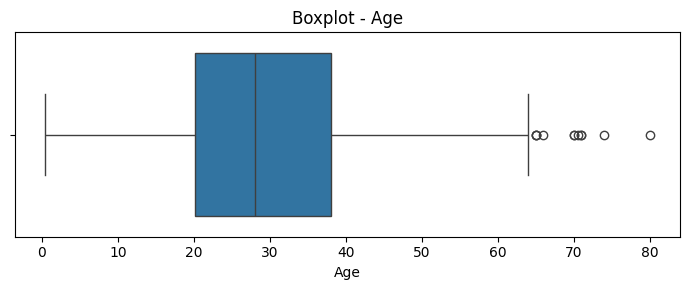

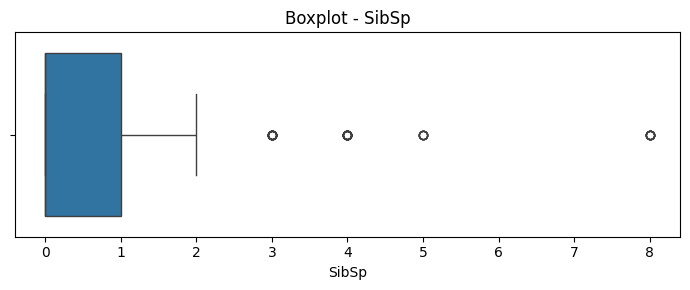

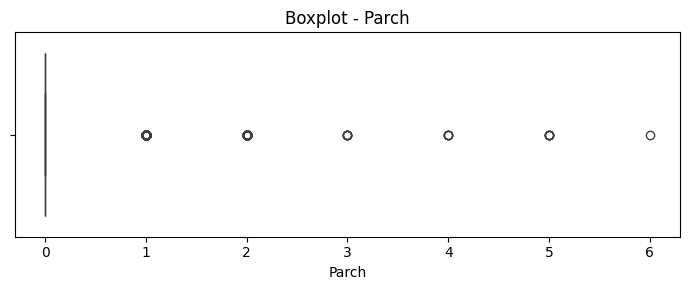

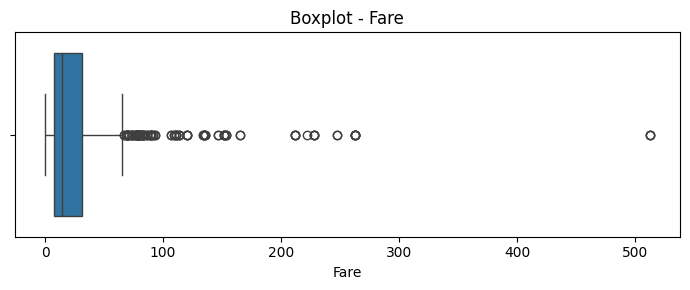

In [3]:
num_cols = ["Age","SibSp","Parch","Fare"]
rows=[]
for c in num_cols:
    s=df[c].dropna()
    q1,q3=s.quantile(.25),s.quantile(.75); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    iqr_n=((s<lo)|(s>hi)).sum()
    zs=np.abs(zscore(s)) if s.std()!=0 else np.zeros(len(s))
    z_n=(zs>3).sum()
    rows.append([c,q1,q3,iqr,lo,hi,int(iqr_n),round(iqr_n/len(s)*100,2),int(z_n)])
outliers=pd.DataFrame(rows,columns=["attribute","Q1","Q3","IQR","lower","upper","IQR_count","IQR_percent","Zscore_count"])
display(outliers)
outliers.to_csv("outputs/outlier_report.csv",index=False,encoding="utf-8-sig")

for c in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot - {c}")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/boxplot_{c}.png",dpi=140)
    plt.show()

## 5. Đề xuất thêm/xóa/biến đổi thuộc tính

**Xóa khỏi đầu vào trực tiếp:** `PassengerId` (ID), `Name` nguyên gốc, `Ticket` nguyên gốc, `Cabin` nguyên gốc.  
**Thuộc tính dẫn xuất:** `Title`, `FamilySize`, `IsAlone`, `CabinKnown`, `Deck`, `AgeMissing`, `LogFare`.  
**Mã hóa:** One-Hot cho biến danh nghĩa.  
**Chuẩn hóa:** StandardScaler cho biến số trong Logistic Regression và KMeans.  
**Leakage:** không dùng `Survived` làm đặc trưng; không tạo biến từ thông tin hậu kết quả.

In [4]:
data=df.copy()
data["Title"]=data["Name"].str.extract(r",\s*([^.]*)\.",expand=False).str.strip()
data["Title"]=data["Title"].replace(["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],"Rare")
data["FamilySize"]=data["SibSp"]+data["Parch"]+1
data["IsAlone"]=(data["FamilySize"]==1).astype(int)
data["CabinKnown"]=data["Cabin"].notna().astype(int)
data["Deck"]=data["Cabin"].fillna("U").str[0]
data["AgeMissing"]=data["Age"].isna().astype(int)
data["LogFare"]=np.log1p(data["Fare"])

X=data.drop(columns=["Survived","PassengerId","Name","Ticket","Cabin","Fare"])
y=data["Survived"]

num_features=X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_features=X.select_dtypes(include=["object","category"]).columns.tolist()

pre=ColumnTransformer([
    ("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),num_features),
    ("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cat_features)
])
print("Features:",list(X.columns))

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'CabinKnown', 'Deck', 'AgeMissing', 'LogFare']


## 6. Thực nghiệm 1 — Phân lớp

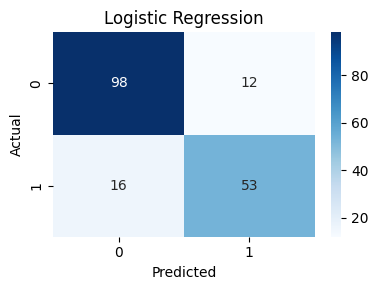

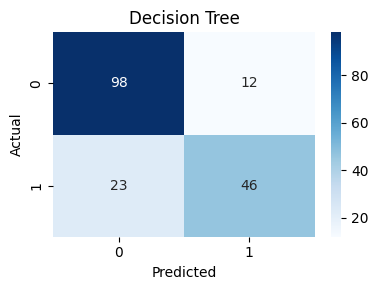

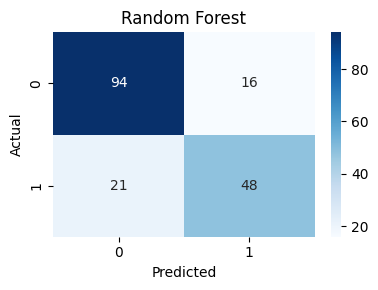

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.843575,0.815385,0.768116,0.791045,0.867194
1,Decision Tree,0.804469,0.793103,0.666667,0.724409,0.823913
2,Random Forest,0.793296,0.750000,0.695652,0.721805,0.820883


In [5]:
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
models={
    "Logistic Regression":LogisticRegression(max_iter=3000,random_state=42),
    "Decision Tree":DecisionTreeClassifier(max_depth=6,random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=300,random_state=42,class_weight="balanced")
}
results=[]
for name,model in models.items():
    pipe=Pipeline([("pre",pre),("model",model)])
    pipe.fit(Xtr,ytr); pred=pipe.predict(Xte); prob=pipe.predict_proba(Xte)[:,1]
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(yte,pred),
        "Precision":precision_score(yte,pred,zero_division=0),
        "Recall":recall_score(yte,pred,zero_division=0),
        "F1":f1_score(yte,pred,zero_division=0),
        "ROC_AUC":roc_auc_score(yte,prob)
    })
    cm=confusion_matrix(yte,pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(name); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(f"outputs/figures/cm_{name.replace(' ','_')}.png",dpi=140); plt.show()

cls_results=pd.DataFrame(results).sort_values("F1",ascending=False)
display(cls_results)
cls_results.to_csv("outputs/classification_results.csv",index=False,encoding="utf-8-sig")

## 7. Thực nghiệm 2 — Gom cụm

Gom cụm dùng dữ liệu **không có nhãn `Survived`**. KMeans được thử với nhiều giá trị `k`; chọn `k` theo silhouette score. Sau đó dùng PCA để trực quan hóa cụm.

,k,inertia,silhouette
0,2,4066.566340,0.398230
1,3,3066.312637,0.405142
2,4,2406.519316,0.427302
3,5,2058.845321,0.431985
4,6,1776.450767,0.440732
5,7,1607.334682,0.444116
6,8,1452.366636,0.450149


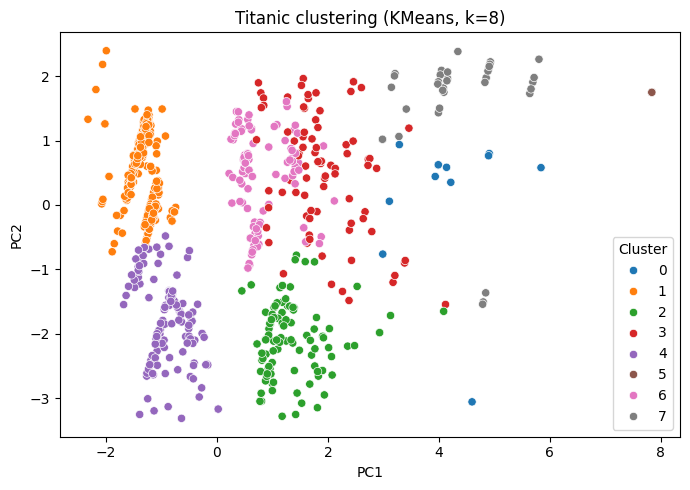

,Pclass,Age,SibSp,Parch,LogFare,FamilySize,IsAlone
Cluster,,,,,,,
0,2.69,41.77,0.85,4.31,3.58,6.15,0.0
1,2.79,28.16,0.00,0.00,2.23,1.00,1.0
2,1.08,38.81,0.82,0.53,4.39,2.35,0.0
3,2.30,14.49,0.64,1.54,3.28,3.18,0.0
4,1.22,40.24,0.00,0.00,3.65,1.00,1.0
5,3.00,28.00,8.00,2.00,4.26,11.00,0.0
6,2.70,28.46,1.08,0.23,2.87,2.32,0.0
7,2.85,10.87,3.67,1.59,3.62,6.26,0.0


In [6]:
from sklearn.decomposition import PCA

cluster_cols=["Pclass","Age","SibSp","Parch","LogFare","FamilySize","IsAlone"]
cluster_df=data[cluster_cols].copy()
cluster_df["Age"]=cluster_df["Age"].fillna(cluster_df["Age"].median())
Z=StandardScaler().fit_transform(cluster_df)

cluster_scores=[]
for k in range(2,9):
    km=KMeans(n_clusters=k,random_state=42,n_init=20)
    labels=km.fit_predict(Z)
    cluster_scores.append({"k":k,"inertia":km.inertia_,"silhouette":silhouette_score(Z,labels)})

cluster_results=pd.DataFrame(cluster_scores)
display(cluster_results)
cluster_results.to_csv("outputs/clustering_scores.csv",index=False,encoding="utf-8-sig")

best_k=int(cluster_results.loc[cluster_results["silhouette"].idxmax(),"k"])
km=KMeans(n_clusters=best_k,random_state=42,n_init=20)
labels=km.fit_predict(Z)

pca=PCA(n_components=2,random_state=42)
P=pca.fit_transform(Z)
plot=pd.DataFrame({"PC1":P[:,0],"PC2":P[:,1],"Cluster":labels})
plt.figure(figsize=(7,5))
sns.scatterplot(data=plot,x="PC1",y="PC2",hue="Cluster",palette="tab10")
plt.title(f"Titanic clustering (KMeans, k={best_k})")
plt.tight_layout()
plt.savefig("outputs/figures/d1_clusters.png",dpi=150)
plt.show()

profile=cluster_df.copy()
profile["Cluster"]=labels
display(profile.groupby("Cluster").mean(numeric_only=True).round(2))

## 8. Kết luận D1

- **Phân lớp khả thi** vì `Survived` là nhãn nhị phân.
- **Gom cụm khả thi** vì có nhiều thuộc tính mô tả hành khách và không cần nhãn.
- So sánh các mô hình bằng Accuracy, Precision, Recall, F1, ROC-AUC.
- Chọn số cụm dựa trên Silhouette score, đồng thời kiểm tra Inertia.
- Quyết định ngoại lai được dựa trên ý nghĩa lĩnh vực, không chỉ dựa vào IQR/Z-score.